In [1]:
import os
wdir=!echo $PWD
os.chdir("/home6/afahad/.ipython/")
from aoespy import *
os.chdir(wdir[0])

/home6/afahad/.ipython/aoespy.py:19: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
import xarray as xr

In [3]:
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

In [6]:
def readmit(exp='GEOSMIT35_ctrl',loc='/nobackupp27/afahad/exp/IAU_exp/',var=4,start_date='20050501',nfiles=120,freq='D',nz=50, nf=7, ni=90, nj=90, ntile=13):
    
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    os.chdir(loc+exp+'/plot')
    pdir='../plots_CLIM/ocean_mit/'
    vdir='/nobackupp27/afahad/mit_diag/'
    try:
        os.system('mkdir -p '+pdir)
    except:
        None

    bathy = ecco.read_llc_to_tiles(input_dir, input_file)

    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


    expdir='../mit_output/'
    restarts='../restarts/'

    os.chdir(expdir)
    files=np.array(sorted(glob('state_3d_set1*.data'))[0:nfiles])
    time=pd.date_range(start_date,periods=len(files),freq=freq)
    
    djf_files=files

    nt=len(time); 

    ndjf=len(djf_files)

    theta_djf=np.zeros((ndjf,nz,ntile,nj,ni)); theta_djf[:]=np.nan
    
    print('reading files')
    for i in range(ndjf):
        print(djf_files[i])
        data=ecco.read_llc_to_tiles(expdir, djf_files[i], nk=-1,nl=-1)
        data=np.reshape(data, (nf,nz,ntile,nj,ni))
        theta_djf[i,:,:,:]=data[var,:,:,:,:]
    return (theta_djf, time)
    
def llc2grd(theta_djf,nz=50):
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
    theta_djf_all=np.zeros(theta_djf.shape)
    theta_djf_all[:]=theta_djf

    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 91

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_lat=np.arange(-90,91,1); nlat=len(new_lat)
    new_lon=np.arange(-180,180,1); nlon=len(new_lon)

    tt=len(theta_djf)
    theta_djf_alli=np.zeros((tt,nz,nlat,nlon))

    for i in range(tt):
        for j in range(nz):

            new_grid_lon_centers, new_grid_lat_centers,\
            new_grid_lon_edges, new_grid_lat_edges,\
            theta_djf_alli[i,j,:,:] =\
                    ecco.resample_to_latlon(ecco_grid.XC, \
                                            ecco_grid.YC, \
                                            theta_djf_all[i,j,:,:,:],\
                                            new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                            new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                            fill_value = np.NaN, \
                                            mapping_method = 'nearest_neighbor',
                                            radius_of_influence = 120000)
    return (np.squeeze(theta_djf_alli), new_lon, new_lat)


In [43]:
def readmit2d(exp='GEOSMIT35_ctrl',loc='/nobackupp27/afahad/exp/IAU_exp/',var=4,start_date='20050501',nfiles=120,freq='D', nf=7, ni=90, nj=90, ntile=13):
    
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    os.chdir(loc+exp+'/plot')
    pdir='../plots_CLIM/ocean_mit/'
    vdir='/nobackupp27/afahad/mit_diag/'
    try:
        os.system('mkdir -p '+pdir)
    except:
        None

    bathy = ecco.read_llc_to_tiles(input_dir, input_file)

    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


    expdir='../mit_output/'
    restarts='../restarts/'

    os.chdir(expdir)
    files=np.array(sorted(glob('state_2d_set1*.data'))[0:nfiles])
    time=pd.date_range(start_date,periods=len(files),freq=freq)
    
    djf_files=files

    nt=len(time); 

    ndjf=len(djf_files)

    theta_djf=np.zeros((ndjf,ntile,nj,ni)); theta_djf[:]=np.nan
    
    print('reading files')
    for i in range(ndjf):
        print(djf_files[i])
        data=ecco.read_llc_to_tiles(expdir, djf_files[i], nk=-1,nl=-1)
        data=np.reshape(data, (nf,ntile,nj,ni))
        theta_djf[i,:,:,:]=data[var,:,:,:]
    return (theta_djf, time)
    
def llc2grd(theta_djf):
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
    theta_djf_all=np.zeros(theta_djf.shape)
    theta_djf_all[:]=theta_djf

    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 91

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_lat=np.arange(-90,91,1); nlat=len(new_lat)
    new_lon=np.arange(-180,180,1); nlon=len(new_lon)

    tt=len(theta_djf)
    theta_djf_alli=np.zeros((tt,nlat,nlon))

    for i in range(tt):

            new_grid_lon_centers, new_grid_lat_centers,\
            new_grid_lon_edges, new_grid_lat_edges,\
            theta_djf_alli[i,:,:] =\
                    ecco.resample_to_latlon(ecco_grid.XC, \
                                            ecco_grid.YC, \
                                            theta_djf_all[i,:,:,:],\
                                            new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                            new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                            fill_value = np.NaN, \
                                            mapping_method = 'nearest_neighbor',
                                            radius_of_influence = 120000)
    return (np.squeeze(theta_djf_alli), new_lon, new_lat)


In [54]:
ME506, time=readmit2d('GEOSMIT_ME05062',var=4,nfiles=15,nf=11,freq='D',start_date='20050506')
ME506,lon,lat=llc2grd(ME506)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_2d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000000252.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000252.data
load_binary_array: loading all 2D

In [46]:
# ME506, time=readmit('GEOSMIT_ME05062',var=1,nz=50,nfiles=30,nf=6,freq='12H',start_date='20050506')
# ME506=ME506[:,0:1,:,:,:]
# ME506,lon,lat=llc2grd(ME506,nz=1)

In [55]:
RP506, time=readmit2d('GEOSMIT_RP0506',var=4,nfiles=15,nf=11,freq='D',start_date='20050506')
RP506,lon,lat=llc2grd(RP506)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_2d_set1.0000015996.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000015996.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000016188.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000016188.data
load_binary_array: loading all 2D

In [56]:
ds = xr.Dataset(
    {
        "RP506": (["time", "lat", "lon"], RP506),
        "ME506": (["time", "lat", "lon"], ME506)
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon
    }
)

ME506=ds.ME506.sel(time=slice('2005-05','2005-06'))

RP506=ds.RP506.sel(time=slice('2005-05','2005-06'))

Q=xr.merge([ME506,RP506])
Q.to_netcdf("/nobackupp27/afahad/exp/IAU_exp/mitdata/Q.nc4")

Text(0, 0.5, 'C')

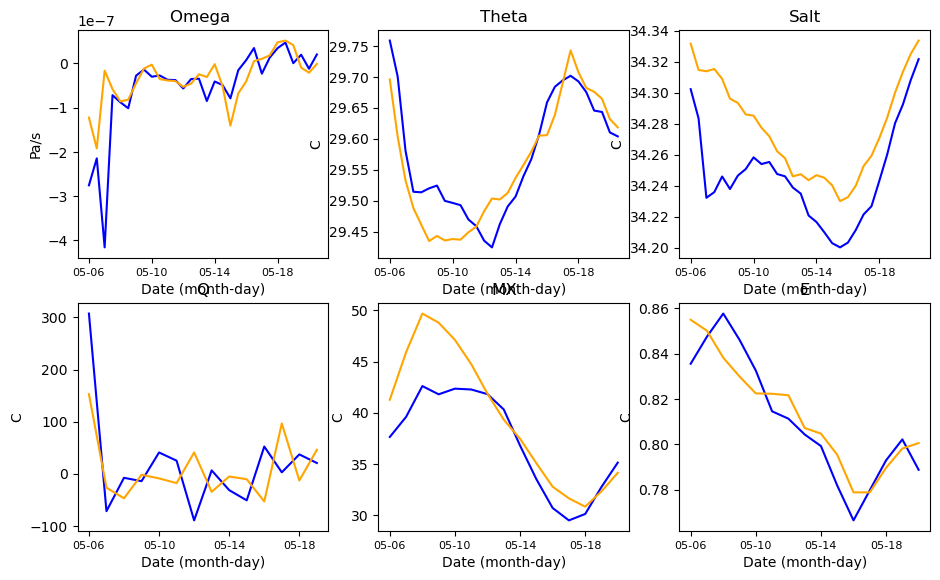

In [72]:
ticks = []

for i in range(len(W.ME506.time)):
    ticks.append(str(W.ME506.time.data[i])[5:10])

plt.figure(figsize=(11, 6.5))
    
x1 = 143
x2 = 143
y1 = -1
y2 = -1

plt.subplot(2, 3, 1)
plt.plot((W.ME506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((W.RP506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Omega ')
plt.xticks(arange(len(ticks))[::8],ticks[::8],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('Pa/s')

plt.subplot(2, 3, 2)
plt.plot((T.ME506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((T.RP506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Theta')
plt.xticks(arange(len(ticks))[::8],ticks[::8],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('C')


plt.subplot(2, 3, 3)
plt.plot((S.ME506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((S.RP506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Salt')
plt.xticks(arange(len(ticks))[::8],ticks[::8],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('C')

ticks = []

for i in range(len(Q.ME506.time)):
    ticks.append(str(Q.ME506.time.data[i])[5:10])


plt.subplot(2, 3, 4)
plt.plot((Q.ME506[:-1]-Q.ME506[1:].data).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((Q.RP506[:-1]-Q.RP506[1:].data).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('Q')
plt.xticks(arange(len(ticks))[::4],ticks[::4],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('C')

plt.subplot(2, 3, 5)
plt.plot((MX.ME506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((MX.RP506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('MX')
plt.xticks(arange(len(ticks))[::4],ticks[::4],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('C')


plt.subplot(2, 3, 6)
plt.plot((E.ME506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((E.RP506).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('E')
plt.xticks(arange(len(ticks))[::4],ticks[::4],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('C')



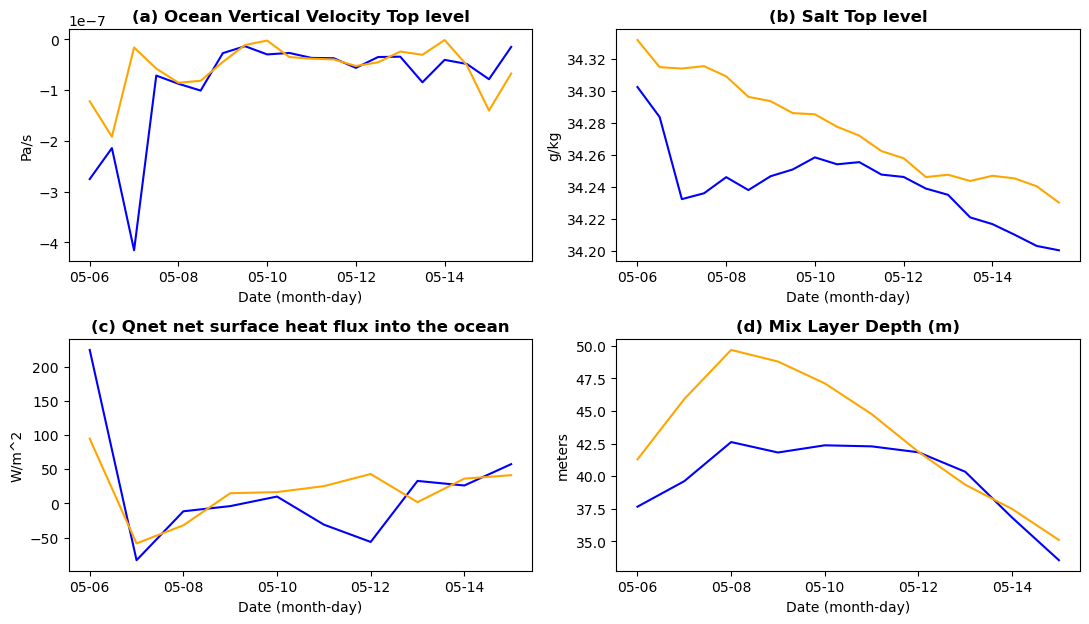

In [ ]:
plt.Figure(figsize=(11,7))
ticks = []

for i in range(len(W.ME506.time)):
    ticks.append(str(W.ME506.time.data[i])[5:10])

plt.figure(figsize=(11, 6.5))
    
x1 = 143
x2 = 143
y1 = -1
y2 = -1

plt.subplot(2, 2, 1)
plt.plot((W.ME506).sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((W.RP506).sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(a) Ocean Vertical Velocity Top level',fontsize=12,fontweight='bold')
plt.xticks(arange(len(ticks[:20]))[::4],ticks[:20][::4],fontsize=10);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

plt.subplot(2, 2, 2)
plt.plot((S.ME506).sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((S.RP506).sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(b) Salt Top level',fontsize=12,fontweight='bold')
plt.xticks(arange(len(ticks[:20]))[::4],ticks[:20][::4],fontsize=10);
plt.xlabel('Date (month-day)')
plt.ylabel('g/kg')

ticks = []

for i in range(len(Q.ME506.time)):
    ticks.append(str(Q.ME506.time.data[i])[5:10])


plt.subplot(2, 2, 3)
plt.plot(Q.ME506.sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot(Q.RP506.sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(c) Qnet net surface heat flux into the ocean',fontsize=12,fontweight='bold')
plt.xticks(arange(len(ticks[:10]))[::2],ticks[:10][::2],fontsize=10);
plt.xlabel('Date (month-day)')
plt.ylabel('W/m^2')

plt.subplot(2, 2, 4)
plt.plot((MX.ME506).sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='blue')
plt.plot((MX.RP506).sel(time=slice('2005-05-05','2005-05-15')).sel(lat=slice(y1, y2), lon=slice(x1, x2)).mean(dim=['lon', 'lat']), color='orange')
plt.title('(d) Mix Layer Depth (m)',fontsize=12,fontweight='bold')
plt.xticks(arange(len(ticks[:10]))[::2],ticks[:10][::2],fontsize=10);
plt.xlabel('Date (month-day)')
plt.ylabel('meters')

plt.tight_layout()



In [27]:
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from IPython.display import HTML, Image

# # Set working directory if needed
# os.chdir('/nobackupp27/afahad/exp/script_replay_AGU/')

# # Example level array
# clf = np.array([-9, -6, 6, 9]) * 1e-8  # Preset levels for colorbar

# # Create a figure with Cartopy projection
# fig, ax = plt.subplots(figsize=(11,8.5),subplot_kw={'projection': ccrs.PlateCarree()})

# # Add geographic features
# ax.coastlines()
# #ax.add_feature(cfeature.BORDERS, linestyle=':')
# # ax.add_feature(cfeature.LAND, edgecolor='black')
# # ax.add_feature(cfeature.LAKES, edgecolor='black')
# # ax.add_feature(cfeature.RIVERS)

# # Add colorbar
# cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='PuOr_r', norm=plt.Normalize(vmin=clf.min(), vmax=clf.max())), ax=ax)
# cbar.set_label('Colorbar Label')  # Customize label as needed

# # Animation function
# def animate2(i):
#     ax.clear()  # Clear the axis to reset the plot for the next frame
#     ax.coastlines()
#     #ax.add_feature(cfeature.BORDERS, linestyle=':')
# #     ax.add_feature(cfeature.LAND, edgecolor='black')
# #     ax.add_feature(cfeature.LAKES, edgecolor='black')
# #     ax.add_feature(cfeature.RIVERS)
    
#     cs = ax.contourf(lon, lat, cntrlN_w[i, :, :] - iauf_w[i, :, :], levels=clf, cmap='PuOr_r', extend='both', transform=ccrs.PlateCarree())
#     ax.set_title(f"Time: {time1[i]}", loc='center', pad=20)
#     ax.set_xlabel('Longitude')
#     ax.set_ylabel('Latitude')
#     return cs

# ani = animation.FuncAnimation(fig, animate2, frames=range(0, 60, 1), interval=800, repeat=False)

# # Generate and display the animation
# HTML(ani.to_jshtml())

# # Save the animation if needed
# ani.save('animationw.gif', writer='pillow', dpi=80)

# # Display the saved animation
# #Image(filename='animationw.gif')

# #plt.show()


In [28]:
# plt.figure(figsize=(11,8.5))

# clf=arange(-18,19,4)
# clf=np.array([-20,-15,-10,-5,5,10,15,20])
# plot(np.nanmean(cntrlN_w[:60,:,:],0)-np.nanmean(iauf_w[:60,:,:],0),lon,lat,clf=np.array([-2,-1.5,-1,-.5,.5,1,1.5,2])*3*1e-8, lat1=-60, lat2=60, cmap='PuOr_r');
# plt.tight_layout()
# plt.title("STD of MAY2005 daily W, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
# plt.savefig('wSTD.png',dpi=250)

In [21]:
ticks=[]

for i in range(len(RP506.time)):
    ticks=append(ticks,str(RP506.time.data[i])[8:16])

/nobackupp27/afahad/conda/envs/earth/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0.5, 1.0, 'STD of MAY2005 daily W, MERRA2-ECCO IC minus IAU IC')

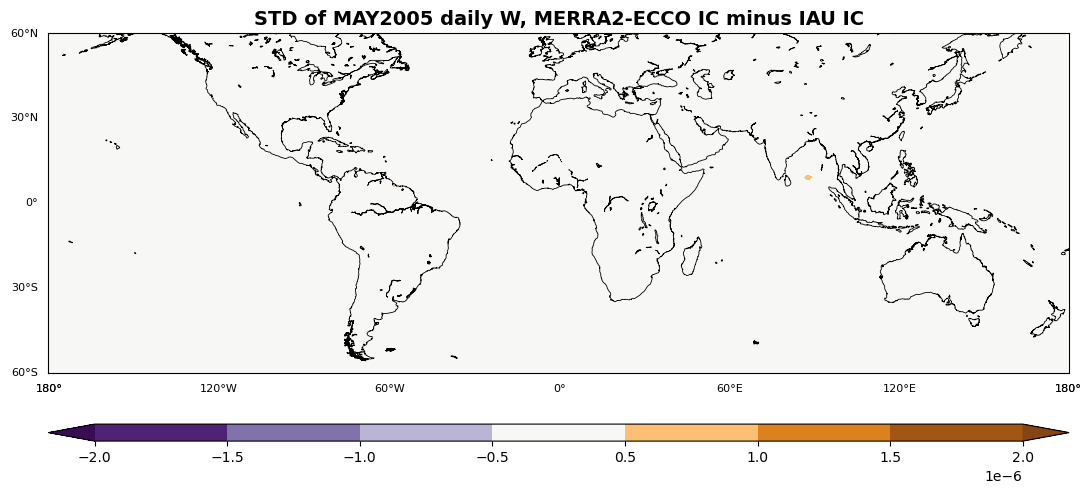

In [22]:
plt.figure(figsize=(11,8.5))

clf=arange(-18,19,4)
clf=np.array([-20,-15,-10,-5,5,10,15,20])*1e-7
plot(np.nanstd(ME506[:60,:,:],0)-np.nanstd(RP506[:60,:,:],0),lon,lat,clf=clf, lat1=-60, lat2=60, cmap='PuOr_r');
plt.tight_layout()
plt.title("STD of MAY2005 daily W, MERRA2-ECCO IC minus IAU IC", fontsize=14, fontweight='bold')
#plt.savefig(pdir+'wSTD.png',dpi=250)

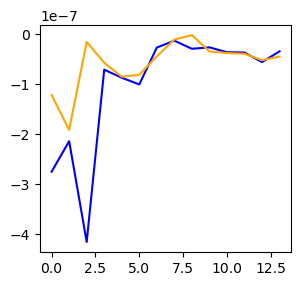

In [ ]:
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

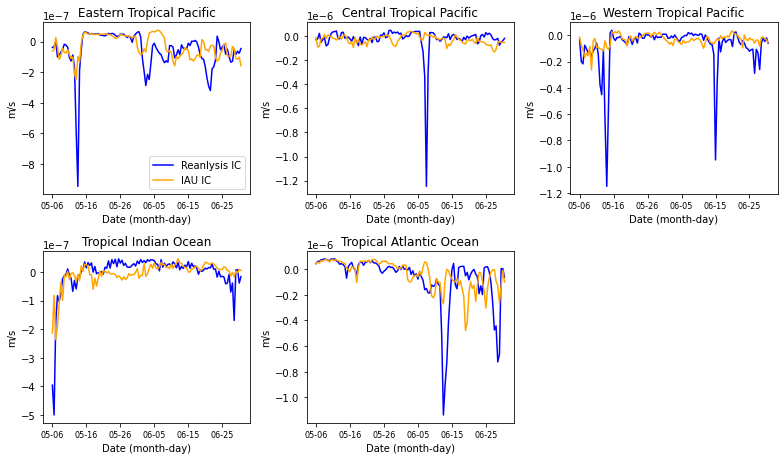

In [ ]:

# x1=-115
# x2=-115
# y1=5
# y2=5

# x1=-79
# x2=-79
# y1=-5
# y2=-5


x1=-127
x2=-127
y1=7
y2=7


plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=136
x2=137
y1=3
y2=4

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('m/s')

x1=90
x2=91
y1=23
y2=25

# plt.subplot(2,3,6)
# # plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# # plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# #plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# #plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# plt.title('Indian Monsoon')
# plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
# plt.xlabel('Date (month-day)')
# plt.ylabel('m/s')

x1=32
x2=35
y1=-1
y2=2


pdir='/nobackupp27/afahad/scripts/initialization_shock/'
plt.tight_layout()
plt.savefig(pdir+'spike_wvel.png',dpi=150)

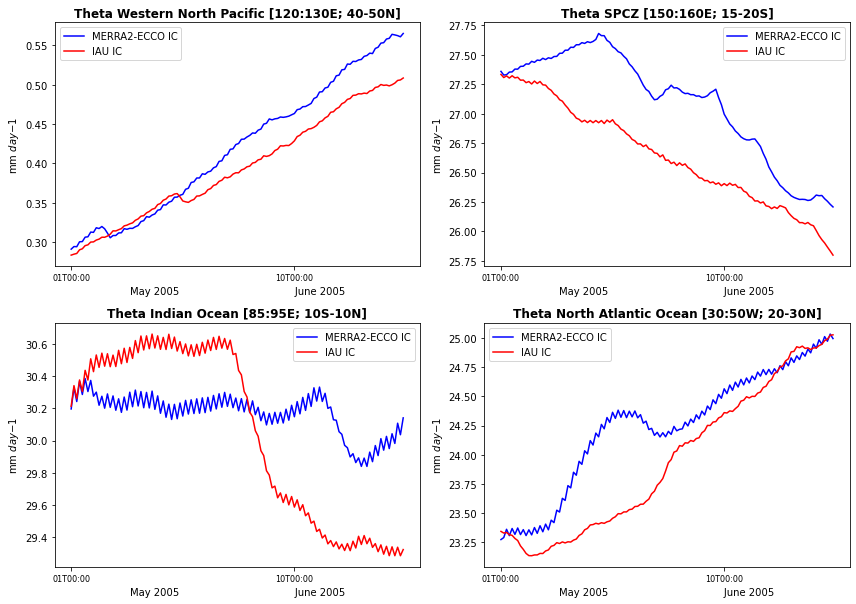

In [ ]:
plt.figure(figsize=(12,8.5))
plt.subplot(2,2,1)

x1=120
x2=130
y1=40
y2=50


lon=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((iauf_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Theta Western North Pacific [120:130E; 40-50N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')

plt.subplot(2,2,2)
x1=150
x2=160
y1=-20
y2=-15

lon=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((iauf_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Theta SPCZ [150:160E; 15-20S]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')


plt.subplot(2,2,3)
x1=85
x2=92
y1=-10
y2=10

lon=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((iauf_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Theta Indian Ocean [85:95E; 10S-10N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')


plt.subplot(2,2,4)


x1=-50
x2=-30
y1=20
y2=30


lon=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lon
lat=(cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).lat

plt.plot((cntrlN_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((iauf_t).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='red')
#plt.plot(fP.sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='black',alpha=.5)
plt.legend(['MERRA2-ECCO IC', 'IAU IC', 'Free Running Exp'])
 
plt.xticks(arange(len(ticks))[::80],ticks[::80],fontsize=8);
plt.title('Theta North Atlantic Ocean [30:50W; 20-30N]',fontweight='bold')
plt.xlabel('May 2005                                     June 2005')
plt.ylabel(r'mm $day{-1}$')

plt.tight_layout()
plt.savefig(pdir+'theta_variability.png',dpi=250)

In [ ]:
rep=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT40_ocniceIAU/holding/geosgcm_surf/200504/GEOSMIT40_ocniceIAU.geosgcm_surf.monthly.200504.nc4').TS_FOUND
rep=rep.mean(dim='time').compute()

In [ ]:
# rep=xr.open_mfdataset('/nobackupp11/afahad/exp/GEOSMIT39_Rep/holding/geosgcm_surf/200504/GEOSMIT39_Rep.geosgcm_surf.monthly.200504.nc4').TS_FOUND
# rep=rep.mean(dim='time').compute()

In [ ]:
ecco=xr.open_dataset('/nobackupp27/afahad/exp/script_replay_AGU/data/THETA_2005_03.nc')

In [ ]:
ob=xr.open_dataset('/nobackupp27/afahad/exp/script_replay_AGU/data/sst.mon.mean.nc')
ob=ob.sst.assign_coords(lon=(((ob.lon + 180) % 360) - 180)).sortby('lon')
ob=ob.sel(time=('2005-03')).mean(dim='time')
ob=ob.interp(lon=rep.lon,lat=rep.lat)

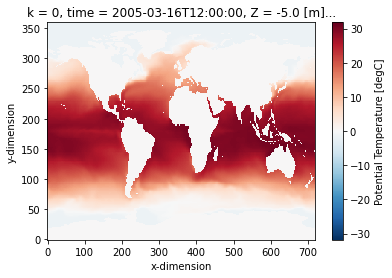

In [ ]:
ecco.THETA[0,0,:,:].plot()

In [ ]:
rep=rep.interp(lon=ecco.longitude,lat=ecco.latitude)

In [ ]:
# rep=xr.open_mfdataset('/nobackupp11/afahad/exp/GEOSMIT34_Freplay2/holding/geosgcm_surf/200505/GEOSMIT34_Freplay2.geosgcm_surf.20050501_*')
# rep=rep.mean(dim='time').compute()

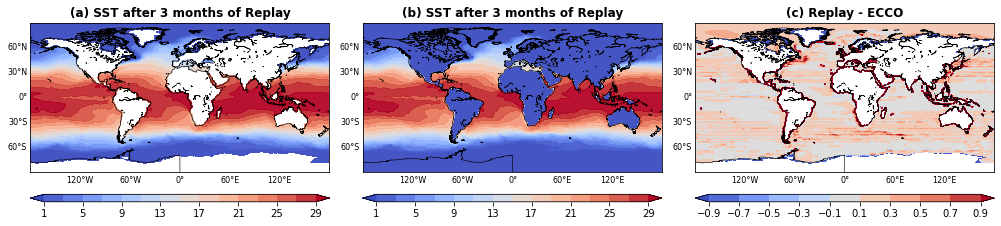

In [ ]:
plt.figure(figsize=(14,12))

plt.subplot(1,3,1)
plot(rep-273.15,clf=arange(1,30,2),lmask=1);
plt.title('(a) SST after 3 months of Replay',fontweight='bold')

plt.subplot(1,3,2)
plot(ecco.THETA[0,0,:,:],rep.lon,rep.lat,clf=arange(1,30,2),lmask=1);
plt.title('(b) SST after 3 months of Replay',fontweight='bold')


plt.subplot(1,3,3)
plot(rep-273.15-ecco.THETA[0,0,:,:],clf=arange(-.9,.91,.2),lmask=1);
plt.title('(c) Replay - ECCO',fontweight='bold');
plt.tight_layout()
#plt.savefig('/nobackupp11/afahad/exp/script_replay_AGU/ocean_state1.png',dpi=150)

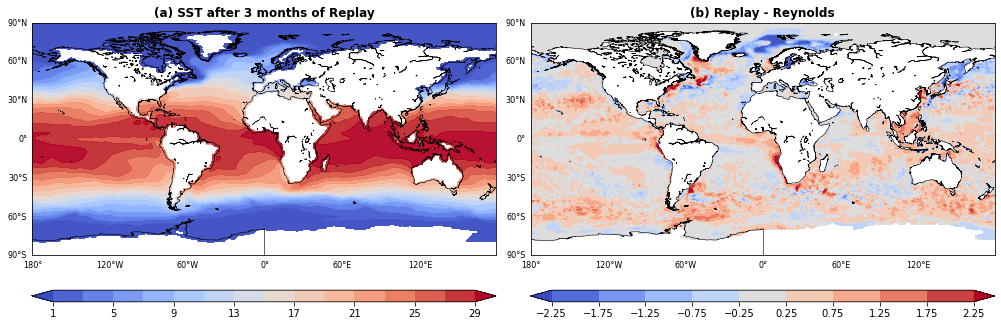

In [ ]:
plt.figure(figsize=(14,12))

plt.subplot(1,2,1)
plot(rep-273.15,clf=arange(1,30,2),lmask=1);
plt.title('(a) SST after 3 months of Replay',fontweight='bold')

plt.subplot(1,2,2)
plot(rep-273.15-ob,clf=arange(-2.25,2.251,.5),lmask=1);
plt.title('(b) Replay - Reynolds',fontweight='bold');
plt.tight_layout()
#plt.savefig('/nobackupp11/afahad/exp/script_replay_AGU/ocean_state1.png',dpi=150)

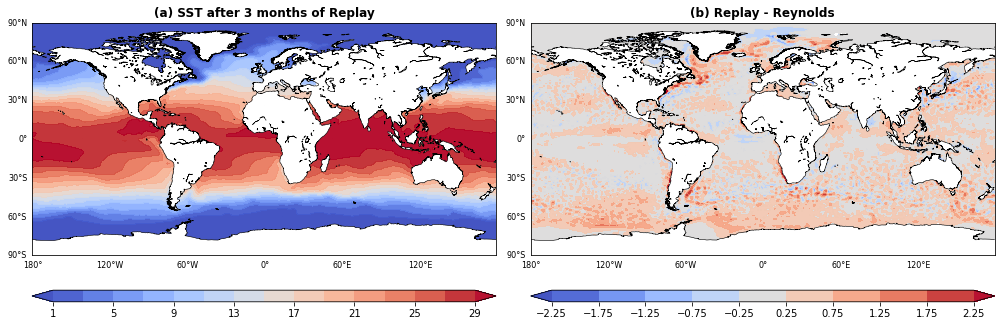

In [ ]:
plt.figure(figsize=(14,12))

plt.subplot(1,2,1)
plot(rep-273.15,clf=arange(1,30,2),lmask=1);
plt.title('(a) SST after 3 months of Replay',fontweight='bold')

plt.subplot(1,2,2)
plot(rep-273.15-ob,clf=arange(-2.25,2.251,.5),lmask=1);
plt.title('(b) Replay - Reynolds',fontweight='bold');
plt.tight_layout()
#plt.savefig('/nobackupp11/afahad/exp/script_replay_AGU/ocean_state1.png',dpi=150)

In [ ]:
ecco_t=xr.open_dataset('/nobackupp27/afahad/exp/script_replay_AGU/data/THETA_2005_04_29.nc').THETA

In [ ]:
ecco_ti=np.squeeze(ecco_ti)
ecco_ti.shape

(50, 181, 360)

In [ ]:
theta_djf_alli.shape

(50, 181, 360)

/tmp/ipykernel_95047/610934194.py:5: RuntimeWarning: Mean of empty slice
  plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli,2),cmap='RdYlBu_r',levels=np.arange(1,31,3),extend='both')
/tmp/ipykernel_95047/610934194.py:14: RuntimeWarning: Mean of empty slice
  plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli-ecco_ti,2),cmap='RdYlBu_r',levels=np.arange(-1.25,1.251,.25),extend='both')


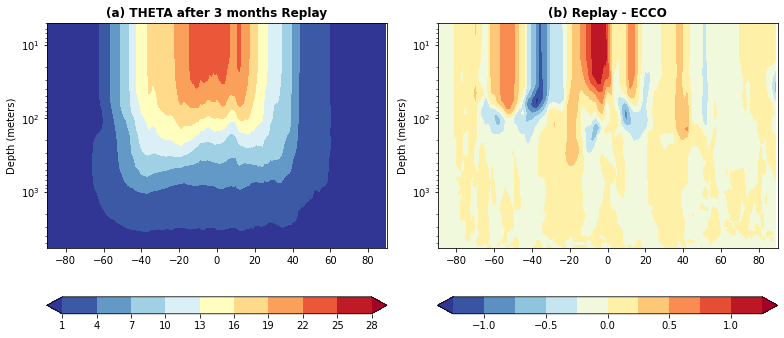

In [ ]:
plt.figure(figsize=(11,5))

plt.subplot(1,2,1)
plt.title('(a) THETA after 3 months Replay',fontweight='bold')
plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli,2),cmap='RdYlBu_r',levels=np.arange(1,31,3),extend='both')
plt.yscale('log')
plt.gca().invert_yaxis()
plt.colorbar(orientation='horizontal')
plt.ylabel('Depth (meters)')


plt.subplot(1,2,2)
plt.title('(b) Replay - ECCO',fontweight='bold')
plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli-ecco_ti,2),cmap='RdYlBu_r',levels=np.arange(-1.25,1.251,.25),extend='both')
plt.yscale('log')
plt.gca().invert_yaxis()
plt.colorbar(orientation='horizontal')
plt.ylabel('Depth (meters)')
plt.tight_layout()

#plt.savefig('/nobackupp11/afahad/exp/script_replay_AGU/ocean_state2.png',dpi=150)

/var/tmp/pbs.20979288.pbspl1.nas.nasa.gov/ipykernel_54857/610934194.py:5: RuntimeWarning: Mean of empty slice
  plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli,2),cmap='RdYlBu_r',levels=np.arange(1,31,3),extend='both')
/var/tmp/pbs.20979288.pbspl1.nas.nasa.gov/ipykernel_54857/610934194.py:14: RuntimeWarning: Mean of empty slice
  plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli-ecco_ti,2),cmap='RdYlBu_r',levels=np.arange(-1.25,1.251,.25),extend='both')


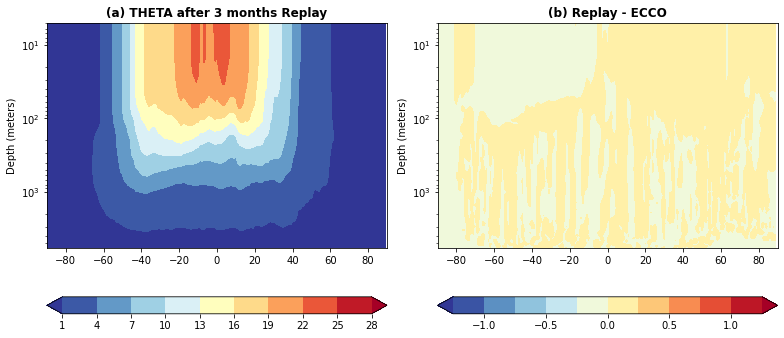

In [ ]:
plt.figure(figsize=(11,5))

plt.subplot(1,2,1)
plt.title('(a) THETA after 3 months Replay',fontweight='bold')
plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli,2),cmap='RdYlBu_r',levels=np.arange(1,31,3),extend='both')
plt.yscale('log')
plt.gca().invert_yaxis()
plt.colorbar(orientation='horizontal')
plt.ylabel('Depth (meters)')


plt.subplot(1,2,2)
plt.title('(b) Replay - ECCO',fontweight='bold')
plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli-ecco_ti,2),cmap='RdYlBu_r',levels=np.arange(-1.25,1.251,.25),extend='both')
plt.yscale('log')
plt.gca().invert_yaxis()
plt.colorbar(orientation='horizontal')
plt.ylabel('Depth (meters)')
plt.tight_layout()

#plt.savefig('/nobackupp11/afahad/exp/script_replay_AGU/ocean_state2.png',dpi=150)

/var/tmp/pbs.20979288.pbspl1.nas.nasa.gov/ipykernel_54857/1940964345.py:5: RuntimeWarning: Mean of empty slice
  plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli,2),cmap='RdYlBu_r',levels=np.arange(1,31,3),extend='both')
/var/tmp/pbs.20979288.pbspl1.nas.nasa.gov/ipykernel_54857/1940964345.py:14: RuntimeWarning: Mean of empty slice
  plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli-ecco_ti,2),cmap='RdYlBu_r',levels=np.arange(-.5,.51,.1),extend='both')


FileNotFoundError: [Errno 2] No such file or directory: '/nobackupp11/afahad/exp/script_replay_AGU/ocean_state2.png'

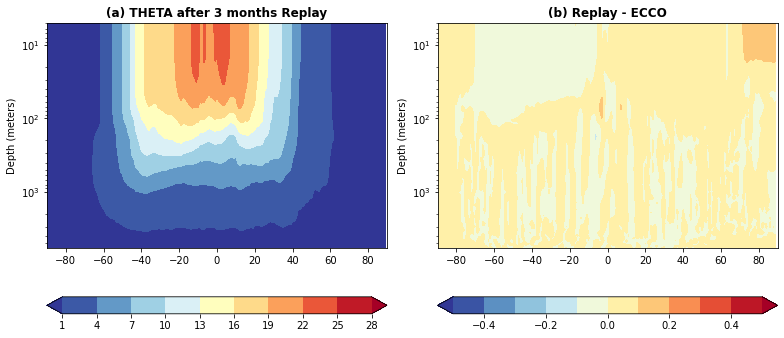

In [ ]:
plt.figure(figsize=(11,5))

plt.subplot(1,2,1)
plt.title('(a) THETA after 3 months Replay',fontweight='bold')
plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli,2),cmap='RdYlBu_r',levels=np.arange(1,31,3),extend='both')
plt.yscale('log')
plt.gca().invert_yaxis()
plt.colorbar(orientation='horizontal')
plt.ylabel('Depth (meters)')


plt.subplot(1,2,2)
plt.title('(b) Replay - ECCO',fontweight='bold')
plt.contourf(new_lat,-ecco_t.Z,np.nanmean(theta_djf_alli-ecco_ti,2),cmap='RdYlBu_r',levels=np.arange(-.5,.51,.1),extend='both')
plt.yscale('log')
plt.gca().invert_yaxis()
plt.colorbar(orientation='horizontal')
plt.ylabel('Depth (meters)')
plt.tight_layout()

plt.savefig('/nobackupp11/afahad/exp/script_replay_AGU/ocean_state2.png',dpi=150)